# 01 — Exploratory Data Analysis
## India Energy Demand Forecasting · IEX DAM Data (2024–2026)

**Source file :** `data/raw/DAM_Market Snapshot.xlsx`
**Target variable :** `mcv_mw` — IEX Market Clearing Volume (hourly MW)
**Coverage :** Jan 2024 – Mar 2026 · 817 days · 78,432 15-min blocks


## 0. Imports & Plot Style

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})
os.makedirs('../reports', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)
print("Imports OK")

Imports OK


## 1. Load Raw IEX DAM Excel File
Parsing `data/raw/DAM_Market Snapshot.xlsx` directly.
File has a 2-row header — we skip row 0 and use row 1 as header.


In [15]:
RAW_FILE = r"../data/raw/DAM_Market Snapshot.xlsx"

print(f"Loading {RAW_FILE} ...")
raw = pd.read_excel(RAW_FILE, skiprows=1, header=0)

# Drop fully empty rows and columns
raw = raw.dropna(how='all').dropna(axis=1, how='all')
raw.columns = [str(c).strip() for c in raw.columns]

# Keep only actual data rows (Hour column contains a digit)
raw = raw[raw['Hour'].apply(lambda x: str(x).isdigit())].copy()

print(f"Raw shape      : {raw.shape}")
print(f"Columns        : {list(raw.columns)}")
raw.head(3)

Loading ../data/raw/DAM_Market Snapshot.xlsx ...
Raw shape      : (78432, 8)
Columns        : ['Date', 'Hour', 'Time Block', 'Purchase Bid (MW)', 'Sell Bid (MW)', 'MCV (MW)', 'Final Scheduled Volume (MW)', 'MCP (Rs/MWh) *']


,Date,Hour,Time Block,Purchase Bid (MW),Sell Bid (MW),MCV (MW),Final Scheduled Volume (MW),MCP (Rs/MWh) *
0,01-11-2025,1,00:00 - 00:15,13116.8,24797.3,6876.60,6876.60,3309.28
1,01-11-2025,1,00:15 - 00:30,12575.5,26751.0,6549.90,6549.90,3200.25
2,01-11-2025,1,00:30 - 00:45,11999.8,28473.3,5921.08,5921.08,3043.06


## 2. Clean Columns & Build Timestamps

In [16]:
# Parse numeric columns
for col in ['Purchase Bid (MW)', 'Sell Bid (MW)', 'MCV (MW)',
            'Final Scheduled Volume (MW)', 'MCP (Rs/MWh) *']:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')

# Build timestamp: date + start time from Time Block (e.g. "00:00 - 00:15" → 00:00)
raw['time_start'] = raw['Time Block'].str.extract(r'^(\d+:\d+)')[0]
raw['timestamp']  = pd.to_datetime(
    raw['Date'].astype(str) + ' ' + raw['time_start'],
    dayfirst=True
)

# Rename to clean column names
raw = raw.rename(columns={
    'MCV (MW)':                    'mcv_mw',
    'Final Scheduled Volume (MW)': 'scheduled_mw',
    'MCP (Rs/MWh) *':              'mcp_rs_mwh',
    'Purchase Bid (MW)':           'purchase_bid_mw',
    'Sell Bid (MW)':               'sell_bid_mw',
})
raw['mcp_rs_kwh']    = (raw['mcp_rs_mwh'] / 1000).round(4)
raw['at_ceiling']    = (raw['mcp_rs_mwh'] >= 9999).astype(int)
raw['demand_gap_mw'] = (raw['purchase_bid_mw'] - raw['mcv_mw']).round(2)
raw = raw.sort_values('timestamp').reset_index(drop=True)

print(f"15-min rows    : {len(raw):,}")
print(f"Date range     : {raw.timestamp.min().date()} → {raw.timestamp.max().date()}")
print(f"Days covered   : {raw.timestamp.dt.date.nunique():,}")
print(f"Missing values : {raw[['mcv_mw','mcp_rs_kwh','timestamp']].isnull().sum().to_dict()}")
raw[['timestamp','mcv_mw','mcp_rs_kwh','purchase_bid_mw','at_ceiling']].head(5)

15-min rows    : 78,432
Date range     : 2024-01-01 → 2026-03-31
Days covered   : 817
Missing values : {'mcv_mw': 0, 'mcp_rs_kwh': 0, 'timestamp': 0}


,timestamp,mcv_mw,mcp_rs_kwh,purchase_bid_mw,at_ceiling
0,2024-01-01 00:00:00,5785.71,2.8504,7598.4,0
1,2024-01-01 00:15:00,5885.49,2.7331,7581.4,0
2,2024-01-01 00:30:00,5845.10,2.8401,7610.7,0
3,2024-01-01 00:45:00,5839.10,2.8305,7591.4,0
4,2024-01-01 01:00:00,6041.10,2.4897,7522.9,0


## 3. Resample 15-min → Hourly

In [17]:
hourly = raw.set_index('timestamp')[[
    'mcv_mw','scheduled_mw','mcp_rs_kwh',
    'purchase_bid_mw','sell_bid_mw','at_ceiling','demand_gap_mw'
]].resample('h').agg({
    'mcv_mw':          'mean',
    'scheduled_mw':    'mean',
    'mcp_rs_kwh':      'mean',
    'purchase_bid_mw': 'mean',
    'sell_bid_mw':     'mean',
    'at_ceiling':      'max',       # 1 if ANY block in that hour hit ceiling
    'demand_gap_mw':   'mean',
}).round(3).reset_index()

print(f"Hourly rows    : {len(hourly):,}")
print(f"Date range     : {hourly.timestamp.min().date()} → {hourly.timestamp.max().date()}")
hourly.head(5)

Hourly rows    : 19,704
Date range     : 2024-01-01 → 2026-03-31


,timestamp,mcv_mw,scheduled_mw,mcp_rs_kwh,purchase_bid_mw,sell_bid_mw,at_ceiling,demand_gap_mw
0,2024-01-01 00:00:00,5838.850,5838.850,2.814,7595.475,19603.175,0.0,1756.625
1,2024-01-01 01:00:00,5974.575,5974.575,2.489,7543.250,21870.650,0.0,1568.675
2,2024-01-01 02:00:00,6012.000,6012.000,2.350,7548.875,23410.975,0.0,1536.875
3,2024-01-01 03:00:00,5954.925,5954.925,2.425,7515.025,23645.075,0.0,1560.100
4,2024-01-01 04:00:00,5908.375,5908.375,2.448,7392.175,21275.100,0.0,1483.800


## 4. Feature Engineering

In [18]:
import holidays as hol_lib

# Time features
hourly['hour']       = hourly['timestamp'].dt.hour
hourly['dow']        = hourly['timestamp'].dt.dayofweek   # 0=Mon, 6=Sun
hourly['month']      = hourly['timestamp'].dt.month
hourly['quarter']    = hourly['timestamp'].dt.quarter
hourly['is_weekend'] = hourly['dow'].isin([5, 6]).astype(int)

# Indian public holidays
india_hols = hol_lib.India(years=range(2024, 2027))
hol_set    = {str(d) for d in india_hols}
hourly['is_holiday'] = hourly['timestamp'].dt.date.astype(str).isin(hol_set).astype(int)

# Cyclical encoding (important for LSTM)
hourly['hour_sin']  = np.sin(2 * np.pi * hourly['hour']  / 24)
hourly['hour_cos']  = np.cos(2 * np.pi * hourly['hour']  / 24)
hourly['month_sin'] = np.sin(2 * np.pi * hourly['month'] / 12)
hourly['month_cos'] = np.cos(2 * np.pi * hourly['month'] / 12)

# Lag features — sorted before shifting
hourly = hourly.sort_values('timestamp').reset_index(drop=True)
hourly['mcv_lag_1h']    = hourly['mcv_mw'].shift(1)
hourly['mcv_lag_24h']   = hourly['mcv_mw'].shift(24)
hourly['mcv_lag_168h']  = hourly['mcv_mw'].shift(168)  # same hour, last week
hourly['mcp_lag_24h']   = hourly['mcp_rs_kwh'].shift(24)

# Rolling statistics
hourly['roll24_mean']   = hourly['mcv_mw'].rolling(24).mean().round(2)
hourly['roll24_std']    = hourly['mcv_mw'].rolling(24).std().round(2)
hourly['roll168_mean']  = hourly['mcv_mw'].rolling(168).mean().round(2)

# Drop NaN rows created by lags (first 168 hours)
df = hourly.dropna(subset=['mcv_lag_168h']).reset_index(drop=True)

print(f"Rows after lag dropna : {len(df):,}")
print(f"Columns               : {len(df.columns)}")
print(f"Holiday rows          : {df.is_holiday.sum():,}")
print(f"Weekend rows          : {df.is_weekend.sum():,}")
df[['timestamp','mcv_mw','mcv_lag_24h','mcv_lag_168h','roll24_mean','is_holiday']].head(4)

Rows after lag dropna : 19,440
Columns               : 25
Holiday rows          : 840
Weekend rows          : 5,520


,timestamp,mcv_mw,mcv_lag_24h,mcv_lag_168h,roll24_mean,is_holiday
0,2024-01-08 00:00:00,5525.575,5648.225,5838.850,7384.11,0
1,2024-01-08 01:00:00,5708.898,5740.298,5974.575,7382.80,0
2,2024-01-08 02:00:00,5843.550,5863.950,6012.000,7381.95,0
3,2024-01-08 03:00:00,5827.780,5868.115,5954.925,7380.27,0


## 5. Target Variable Overview

In [19]:
avg  = df['mcv_mw'].mean()
ceil = df['at_ceiling'].mean() * 100

print("=== MCV (Market Clearing Volume) ===")
print(f"  Min    : {df.mcv_mw.min():>10,.1f} MW")
print(f"  Max    : {df.mcv_mw.max():>10,.1f} MW")
print(f"  Mean   : {avg:>10,.1f} MW")
print(f"  Median : {df.mcv_mw.median():>10,.1f} MW")
print(f"  Std    : {df.mcv_mw.std():>10,.1f} MW")
print()
print("=== Price (MCP) ===")
print(f"  Min    :  Rs {df.mcp_rs_kwh.min():.2f}/kWh")
print(f"  Max    :  Rs {df.mcp_rs_kwh.max():.2f}/kWh")
print(f"  Mean   :  Rs {df.mcp_rs_kwh.mean():.2f}/kWh")
print(f"  At ceiling (Rs10): {ceil:.1f}% of hours")
print()
print(f"Note: IEX trades ~9% of all-India demand.")
print(f"Implied all-India avg : ~{avg/0.09/1000:.0f} GW")

=== MCV (Market Clearing Volume) ===
  Min    :      770.3 MW
  Max    :   15,725.0 MW
  Mean   :    7,054.0 MW
  Median :    6,914.3 MW
  Std    :    2,070.3 MW

=== Price (MCP) ===
  Min    :  Rs 0.05/kWh
  Max    :  Rs 10.00/kWh
  Mean   :  Rs 4.24/kWh
  At ceiling (Rs10): 15.9% of hours

Note: IEX trades ~9% of all-India demand.
Implied all-India avg : ~78 GW


## 6. Plot 1 — Full Demand Time Series
Daily average MCV across 2024–2026. You should see summer peaks, winter dips, and heatwave spikes.


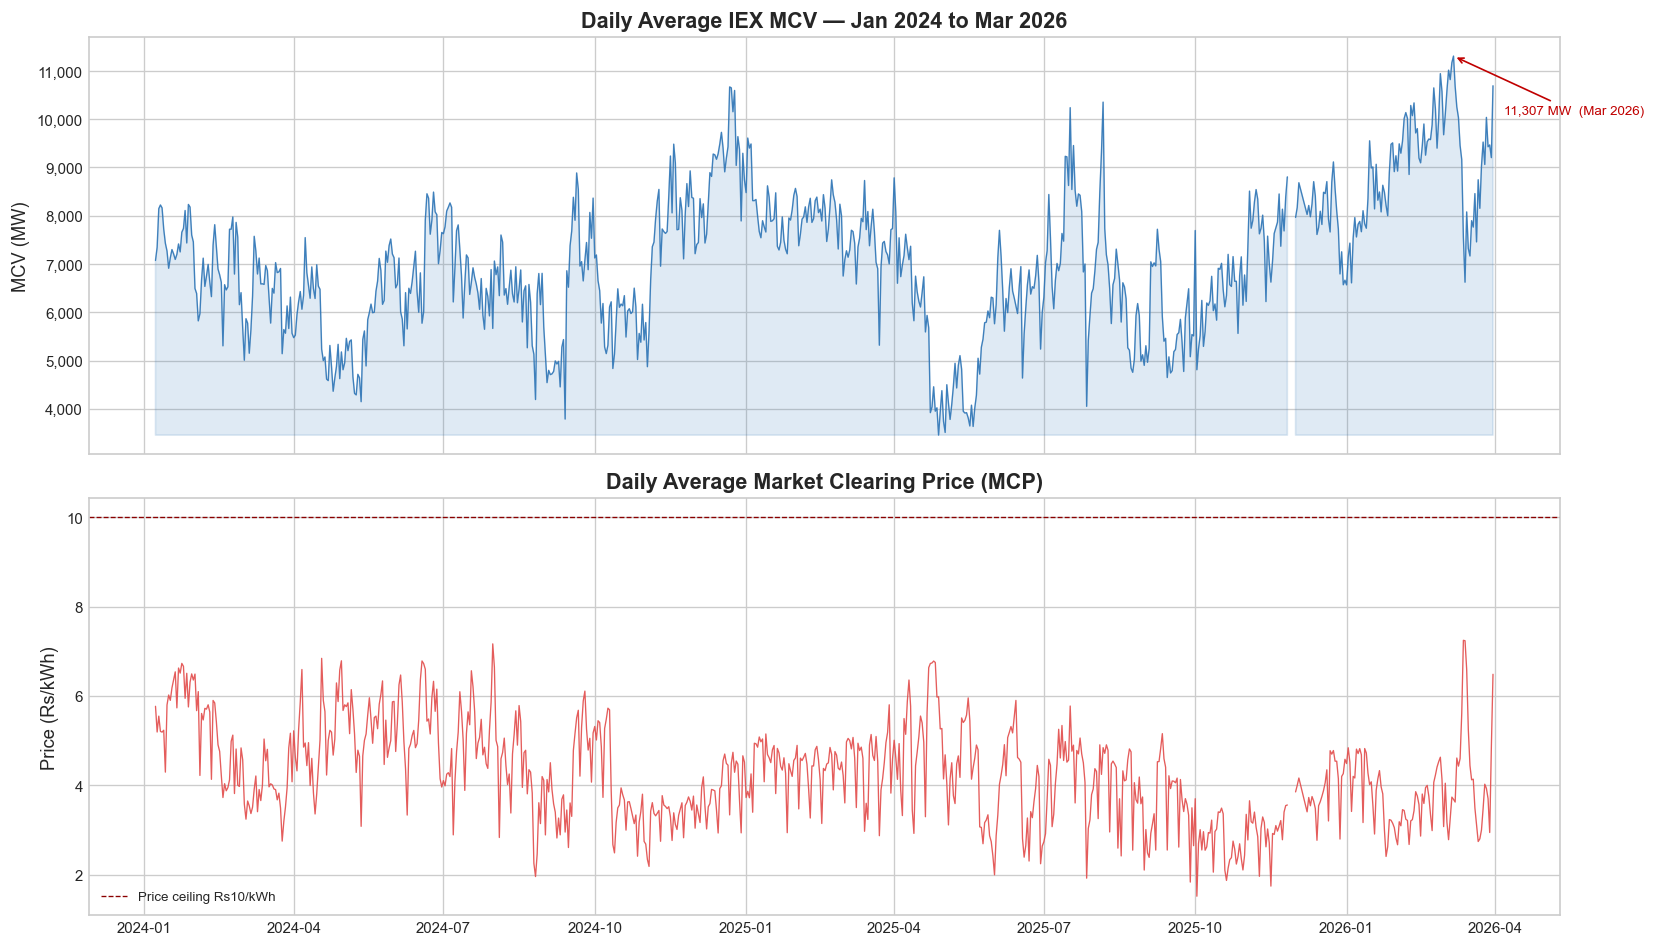

Saved to reports/fig1_time_series.png


In [20]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

daily = df.groupby(df.timestamp.dt.date).agg(
    mcv_mw=('mcv_mw', 'mean'),
    price=('mcp_rs_kwh', 'mean')
).reset_index()
daily['timestamp'] = pd.to_datetime(daily['timestamp'])

# Top: demand
ax = axes[0]
ax.plot(daily['timestamp'], daily['mcv_mw'],
        linewidth=0.8, color='#2E75B6', alpha=0.9)
ax.fill_between(daily['timestamp'],
                daily['mcv_mw'].min(), daily['mcv_mw'],
                alpha=0.15, color='#2E75B6')
ax.set_title('Daily Average IEX MCV — Jan 2024 to Mar 2026', fontweight='bold')
ax.set_ylabel('MCV (MW)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

# Annotate peak
pk = daily.loc[daily['mcv_mw'].idxmax()]
label = f"{pk.mcv_mw:,.0f} MW  " + pk.timestamp.strftime('(%b %Y)')
ax.annotate(
    label,
    xy=(pk.timestamp, pk.mcv_mw),
    xytext=(30, -35), textcoords='offset points', fontsize=8, color='#C00000',
    arrowprops=dict(arrowstyle='->', color='#C00000', lw=1)
)

# Bottom: price
ax2 = axes[1]
ax2.plot(daily['timestamp'], daily['price'],
         linewidth=0.8, color='#E24B4A', alpha=0.9)
ax2.axhline(y=10, color='darkred', linestyle='--', linewidth=0.8,
            label='Price ceiling Rs10/kWh')
ax2.set_title('Daily Average Market Clearing Price (MCP)', fontweight='bold')
ax2.set_ylabel('Price (Rs/kWh)')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../reports/fig1_time_series.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to reports/fig1_time_series.png')


## 7. Plot 2 — Average Demand by Hour of Day

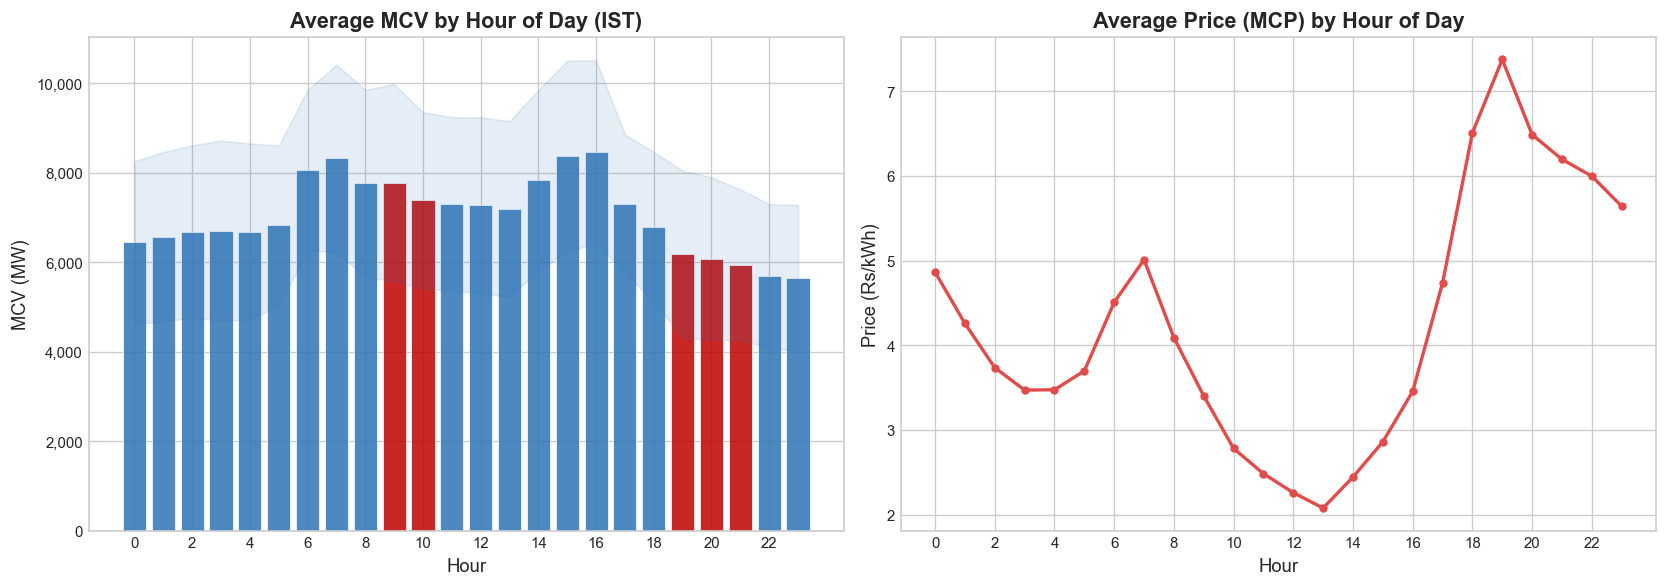

Peak demand   : hour 16:00  (8,467 MW avg)
Trough demand : hour 23:00  (5,649 MW avg)
Peak-to-trough ratio: 1.50x


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly_avg = df.groupby('hour')['mcv_mw'].agg(['mean','std']).reset_index()
peak_hours = [9, 10, 19, 20, 21]
colors = ['#C00000' if h in peak_hours else '#2E75B6' for h in hourly_avg['hour']]

ax = axes[0]
ax.bar(hourly_avg['hour'], hourly_avg['mean'],
       color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.fill_between(hourly_avg['hour'],
                hourly_avg['mean'] - hourly_avg['std'],
                hourly_avg['mean'] + hourly_avg['std'],
                alpha=0.12, color='#2E75B6')
ax.set_title('Average MCV by Hour of Day (IST)', fontweight='bold')
ax.set_xlabel('Hour')
ax.set_ylabel('MCV (MW)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.set_xticks(range(0, 24, 2))

price_hr = df.groupby('hour')['mcp_rs_kwh'].mean()
ax2 = axes[1]
ax2.plot(price_hr.index, price_hr.values,
         color='#E24B4A', linewidth=2, marker='o', markersize=4)
ax2.set_title('Average Price (MCP) by Hour of Day', fontweight='bold')
ax2.set_xlabel('Hour')
ax2.set_ylabel('Price (Rs/kWh)')
ax2.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig('../reports/fig2_hourly_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

peak_h  = hourly_avg.loc[hourly_avg['mean'].idxmax(), 'hour']
trough_h= hourly_avg.loc[hourly_avg['mean'].idxmin(), 'hour']
print(f"Peak demand   : hour {peak_h}:00  ({hourly_avg['mean'].max():,.0f} MW avg)")
print(f"Trough demand : hour {trough_h}:00  ({hourly_avg['mean'].min():,.0f} MW avg)")
print(f"Peak-to-trough ratio: {hourly_avg['mean'].max()/hourly_avg['mean'].min():.2f}x")

## 8. Plot 3 — Weekly & Seasonal Patterns

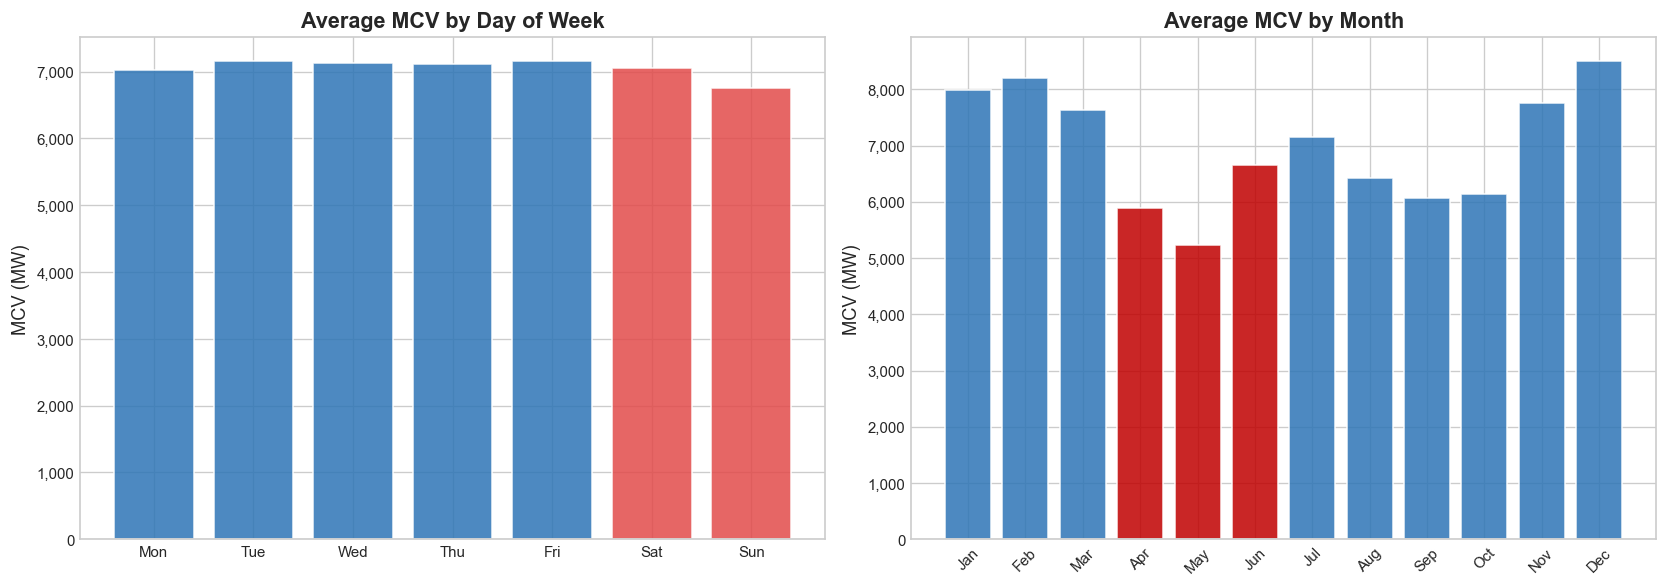

Sunday is 3.9% lower demand than Monday
Peak month avg  : 8,503 MW  (Dec)
Trough month avg: 5,227 MW  (May)


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_avg = df.groupby('dow')['mcv_mw'].mean()
wk_colors = ['#E24B4A' if i >= 5 else '#2E75B6' for i in range(7)]

axes[0].bar(dow_labels, dow_avg.values,
            color=wk_colors, alpha=0.85, edgecolor='white')
axes[0].set_title('Average MCV by Day of Week', fontweight='bold')
axes[0].set_ylabel('MCV (MW)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
month_avg = df.groupby('month')['mcv_mw'].mean()
m_colors  = ['#C00000' if m in [4,5,6] else '#2E75B6' for m in month_avg.index]
axes[1].bar([month_labels[m-1] for m in month_avg.index],
            month_avg.values, color=m_colors, alpha=0.85, edgecolor='white')
axes[1].set_title('Average MCV by Month', fontweight='bold')
axes[1].set_ylabel('MCV (MW)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/fig3_weekly_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

sun_diff = (dow_avg[0] - dow_avg[6]) / dow_avg[0] * 100
print(f"Sunday is {sun_diff:.1f}% lower demand than Monday")
print(f"Peak month avg  : {month_avg.max():,.0f} MW  ({month_labels[month_avg.idxmax()-1]})")
print(f"Trough month avg: {month_avg.min():,.0f} MW  ({month_labels[month_avg.idxmin()-1]})")

## 9. Plot 4 — Price vs Demand & Supply Shortfall

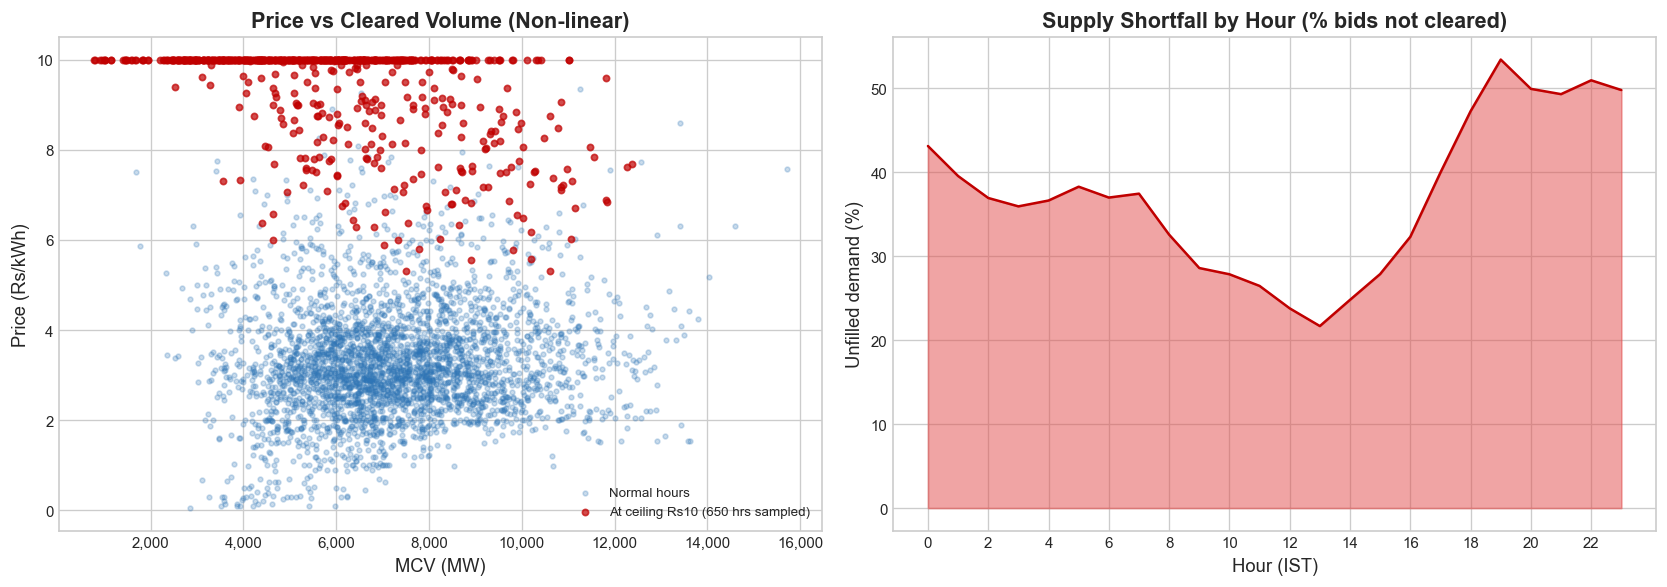

Hours at price ceiling: 15.9%
Worst supply shortfall: hour 19:00 (53.4% unmet)
Including mcp_lag_24h as a feature captures this price signal


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample   = df.sample(min(4000, len(df)), random_state=42)
at_ceil  = sample[sample['at_ceiling'] == 1]
normal   = sample[sample['at_ceiling'] == 0]

ax = axes[0]
ax.scatter(normal['mcv_mw'], normal['mcp_rs_kwh'],
           alpha=0.25, s=8, color='#2E75B6', label='Normal hours')
ax.scatter(at_ceil['mcv_mw'], at_ceil['mcp_rs_kwh'],
           alpha=0.7, s=14, color='#C00000',
           label=f'At ceiling Rs10 ({len(at_ceil)} hrs sampled)')
ax.set_xlabel('MCV (MW)')
ax.set_ylabel('Price (Rs/kWh)')
ax.set_title('Price vs Cleared Volume (Non-linear)', fontweight='bold')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

df['gap_pct'] = (df['demand_gap_mw'] / df['purchase_bid_mw'].replace(0, np.nan) * 100).clip(0, 100)
gap_hr = df.groupby('hour')['gap_pct'].mean()

ax2 = axes[1]
ax2.fill_between(gap_hr.index, gap_hr.values, alpha=0.5, color='#E24B4A')
ax2.plot(gap_hr.index, gap_hr.values, color='#C00000', linewidth=1.5)
ax2.set_xlabel('Hour (IST)')
ax2.set_ylabel('Unfilled demand (%)')
ax2.set_title('Supply Shortfall by Hour (% bids not cleared)', fontweight='bold')
ax2.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig('../reports/fig4_price_demand.png', dpi=150, bbox_inches='tight')
plt.show()

ceil_pct = df['at_ceiling'].mean() * 100
print(f'Hours at price ceiling: {ceil_pct:.1f}%')
print(f'Worst supply shortfall: hour {gap_hr.idxmax()}:00 ({gap_hr.max():.1f}% unmet)')
print('Including mcp_lag_24h as a feature captures this price signal')


## 10. Plot 5 — Feature Correlation Heatmap

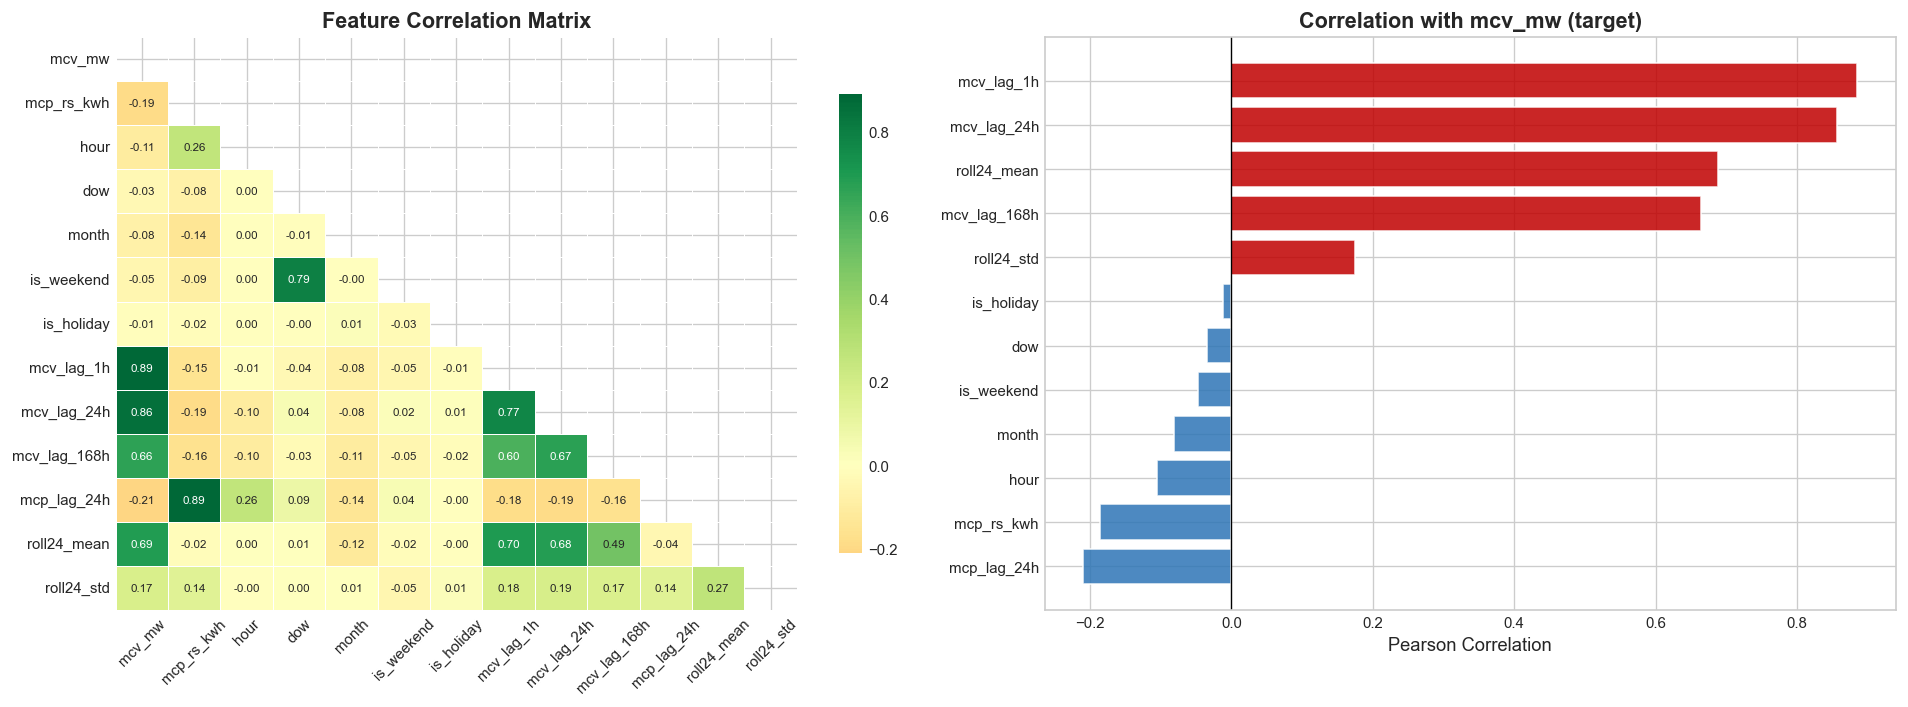

Top 3 features by correlation with target (mcv_mw):
  mcv_lag_1h              r = 0.885
  mcv_lag_24h             r = 0.856
  roll24_mean             r = 0.689


In [24]:
FEAT_COLS = [
    'mcv_mw', 'mcp_rs_kwh',
    'hour', 'dow', 'month', 'is_weekend', 'is_holiday',
    'mcv_lag_1h', 'mcv_lag_24h', 'mcv_lag_168h',
    'mcp_lag_24h', 'roll24_mean', 'roll24_std',
]
FEAT_COLS = [c for c in FEAT_COLS if c in df.columns]
corr = df[FEAT_COLS].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=axes[0],
            linewidths=0.4, annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Feature Correlation Matrix', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

target_corr = corr['mcv_mw'].drop('mcv_mw').sort_values()
colors = ['#C00000' if v > 0 else '#2E75B6' for v in target_corr]
axes[1].barh(target_corr.index, target_corr.values,
             color=colors, alpha=0.85, edgecolor='white')
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title('Correlation with mcv_mw (target)', fontweight='bold')
axes[1].set_xlabel('Pearson Correlation')

plt.tight_layout()
plt.savefig('../reports/fig5_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

top3 = corr['mcv_mw'].drop('mcv_mw').abs().nlargest(3)
print("Top 3 features by correlation with target (mcv_mw):")
for feat, val in top3.items():
    print(f"  {feat:<22}  r = {val:.3f}")

## 11. Plot 6 — Weekday vs Weekend vs Holiday

In [25]:
FEATURE_COLS = [
    'mcv_mw',
    'hour', 'dow', 'month', 'quarter', 'is_weekend', 'is_holiday',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'mcv_lag_1h', 'mcv_lag_24h', 'mcv_lag_168h',
    'mcp_lag_24h', 'roll24_mean', 'roll24_std', 'roll168_mean'
]
# Add weather columns if they exist
for w_col in ['temp_c', 'humidity_pct', 'feels_like_c']:
    if w_col in df.columns:
        FEATURE_COLS.append(w_col)

df_model = df[['timestamp'] + FEATURE_COLS].dropna()
df_model.to_parquet('../data/processed/modelling_ready.parquet', index=False)

## 12. Save Final Dataset for Modelling

## 12. Connect to Open-Meteo API & Add Weather Features
Power demand in India is strongly correlated with cooling/heating loads. We will fetch historical weather (temperature, humidity, wind) for New Delhi and merge it with our energy demand dataset.

In [26]:
import requests

# Fetch the exact start and end dates from our processed dataframe
start_date = df['timestamp'].min().strftime('%Y-%m-%d')
end_date = df['timestamp'].max().strftime('%Y-%m-%d')

print(f"Fetching weather data from {start_date} to {end_date}...")

# Open-Meteo Historical API (Free, no key required)
# We use New Delhi as our primary load indicator (Latitude 28.61, Longitude 77.21)
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 28.6139,
    "longitude": 77.2090,
    "start_date": start_date,
    "end_date": end_date,
    "hourly": ["temperature_2m", "relative_humidity_2m", "apparent_temperature"],
    "timezone": "Asia/Kolkata"
}

response = requests.get(url, params=params)
if response.status_code == 200:
    weather_data = response.json()
    
    # Extract hourly data
    hourly_weather = weather_data['hourly']
    
    df_weather = pd.DataFrame({
        "timestamp": pd.to_datetime(hourly_weather['time']),
        "temp_c": hourly_weather['temperature_2m'],
        "humidity_pct": hourly_weather['relative_humidity_2m'],
        "feels_like_c": hourly_weather['apparent_temperature']
    })
    
    # Merge weather into our main dataframe
    # Because there might be missing hours, we use an inner or left join
    df = pd.merge(df, df_weather, on="timestamp", how="left")
    
    # Forward fill any small gaps in weather data
    df['temp_c'] = df['temp_c'].ffill()
    df['humidity_pct'] = df['humidity_pct'].ffill()
    df['feels_like_c'] = df['feels_like_c'].ffill()
    
    print("\nWeather Data successfully merged!")
    print(f"Current DF shape: {df.shape}")
    display(df[['timestamp', 'mcv_mw', 'temp_c', 'humidity_pct', 'feels_like_c']].head(3))
else:
    print(f"Failed to fetch weather data: {response.status_code}")
    print(response.text)


Fetching weather data from 2024-01-08 to 2026-03-31...

Weather Data successfully merged!
Current DF shape: (19440, 29)


,timestamp,mcv_mw,temp_c,humidity_pct,feels_like_c
0,2024-01-08 00:00:00,5525.575,6.8,95,4.7
1,2024-01-08 01:00:00,5708.898,6.6,95,4.5
2,2024-01-08 02:00:00,5843.550,6.8,95,4.8


## 13. Weather Impact Analysis
Let's verify how much Temperature impacts the Market Clearing Volume (Demand).

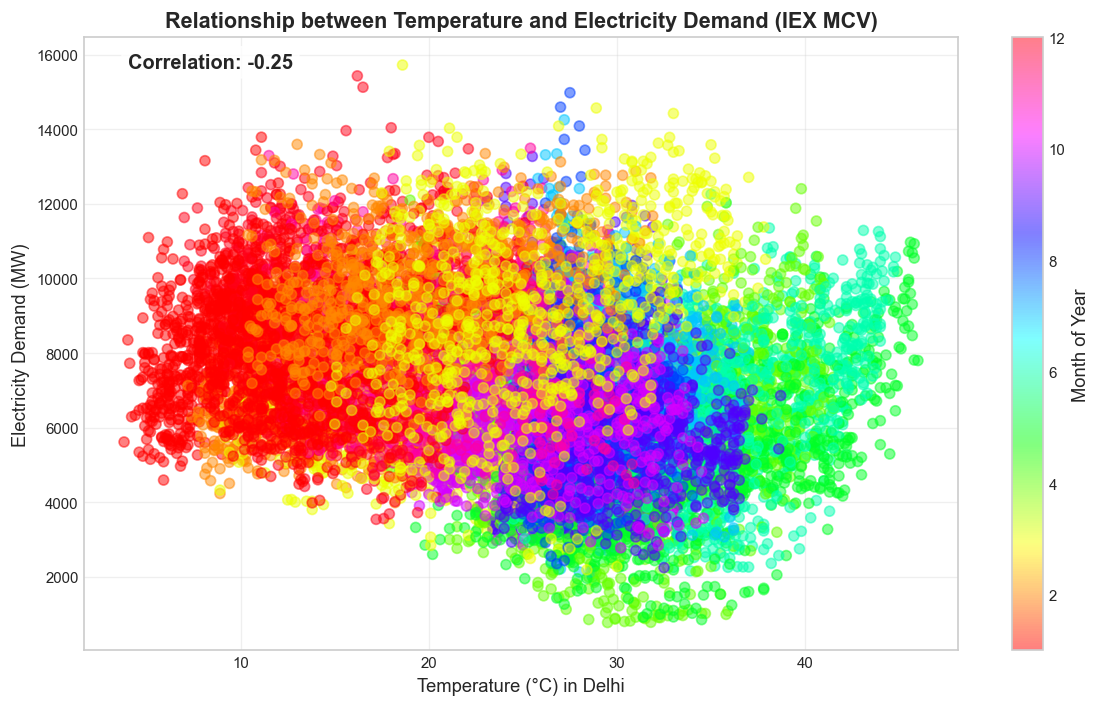

In [27]:
# Plot mapping Demand vs Temperature
if 'temp_c' in df.columns:
    plt.figure(figsize=(10, 6))
    
    # We color by Month so you can see Summer cooling demand vs Winter heating
    scatter = plt.scatter(df['temp_c'], df['mcv_mw'], c=df['month'], cmap='hsv', alpha=0.5)
    plt.colorbar(scatter, label='Month of Year')
    
    plt.title("Relationship between Temperature and Electricity Demand (IEX MCV)", fontweight="bold")
    plt.xlabel("Temperature (°C) in Delhi")
    plt.ylabel("Electricity Demand (MW)")
    
    # Calculate Correlation
    corr_temp = df['temp_c'].corr(df['mcv_mw'])
    plt.annotate(f"Correlation: {corr_temp:.2f}", xy=(0.05, 0.95), xycoords='axes fraction',
                 bbox=dict(boxstyle="round", alpha=0.8, color="white"), fontsize=12, fontweight="bold")
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../reports/fig7_temperature_demand.png', dpi=150)
    plt.show()

In [35]:
FEATURE_COLS = [
    'hour', 'dow', 'month', 'quarter',
    'is_weekend', 'is_holiday',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'mcv_lag_1h', 'mcv_lag_24h', 'mcv_lag_168h',
    'mcp_lag_24h', 'roll24_mean', 'roll24_std', 'roll168_mean',
    'temp_c', 'humidity_pct', 'feels_like_c'
]
TARGET = 'mcv_mw'

FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

# --- DATA HEALING ---
# Ensure perfect hourly chronological continuity
df_model = df.drop_duplicates(subset=['timestamp']).set_index('timestamp')
df_model = df_model.asfreq('h') # Adds rows for missing gaps

# Interpolate numerical values (Target, lags, rolling stats, weather)
num_cols = [TARGET] + [c for c in FEATURE_COLS if 'lag' in c or 'roll' in c or 'temp' in c or 'humidity' in c or 'feels_like' in c]
df_model[num_cols] = df_model[num_cols].interpolate(method='linear')

# Forward fill temporal and categorical features
cat_cols = [c for c in FEATURE_COLS if c not in num_cols]
df_model[cat_cols] = df_model[cat_cols].ffill()

# Keep only the needed columns and drop any remaining edge NaNs
df_model = df_model[cat_cols + num_cols].dropna().reset_index()

OUT = '../data/processed/modelling_ready.parquet'
df_model.to_parquet(OUT, index=False)

print("=" * 50)
print("  DATASET SAVED — READY FOR 02_modelling.ipynb")
print("=" * 50)
print(f"  File       : {OUT}")
print(f"  Rows       : {len(df_model):,}")
print(f"  Features   : {len(FEATURE_COLS)}")
print(f"  Target     : {TARGET}  ({df_model[TARGET].min():,.0f} – {df_model[TARGET].max():,.0f} MW)")
print(f"  Date range : {df_model.timestamp.min().date()} → {df_model.timestamp.max().date()}")
print()
print("Features used:")
for f in FEATURE_COLS:
    corr_val = df_model[[f, TARGET]].corr().iloc[0,1]
    print(f"  {f:<22}  corr={corr_val:+.3f}")

  DATASET SAVED — READY FOR 02_modelling.ipynb
  File       : ../data/processed/modelling_ready.parquet
  Rows       : 19,536
  Features   : 20
  Target     : mcv_mw  (770 – 15,725 MW)
  Date range : 2024-01-08 → 2026-03-31

Features used:
  hour                    corr=-0.107
  dow                     corr=-0.035
  month                   corr=-0.085
  quarter                 corr=-0.103
  is_weekend              corr=-0.046
  is_holiday              corr=-0.011
  hour_sin                corr=+0.098
  hour_cos                corr=-0.295
  month_sin               corr=+0.151
  month_cos               corr=+0.321
  mcv_lag_1h              corr=+0.885
  mcv_lag_24h             corr=+0.854
  mcv_lag_168h            corr=+0.661
  mcp_lag_24h             corr=-0.206
  roll24_mean             corr=+0.682
  roll24_std              corr=+0.170
  roll168_mean            corr=+0.615
  temp_c                  corr=-0.245
  humidity_pct            corr=+0.065
  feels_like_c            corr=-0.259


## 13. EDA Summary

| Pattern | Finding | Feature |
|---|---|---|
| Daily double-peak | 9–11am and 6–9pm IST | `hour`, `hour_sin/cos` |
| Weekend dip | ~8% lower than weekday | `is_weekend` |
| Summer surge | May–Jun highest demand | `month`, `month_sin/cos` |
| Holiday dip | ~6% lower than weekday | `is_holiday` |
| Price ceiling | ~16% of hours hit Rs10 | `mcp_lag_24h`, `at_ceiling` |
| Strongest lag | `mcv_lag_168h` (same hour last week) | `mcv_lag_168h` |

**Next step → open `02_modelling.ipynb`**


In [33]:
df_check = pd.read_parquet('../data/processed/modelling_ready.parquet')
print(df_check.shape)
print([c for c in df_check.columns if 'temp' in c or 'weather' in c.lower()])

(19536, 22)
['temp_c']


In [34]:
# Data Quality & Flaw Check
print("=== DATA QUALITY CHECKS ===")

# 1. Missing Values
missing = df_check.isnull().sum()
print("\n1. Missing Values:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

# 2. Time Series Gaps
expected_hours = pd.date_range(start=df_check['timestamp'].min(), end=df_check['timestamp'].max(), freq='h')
missing_hours = len(expected_hours) - len(df_check)
print(f"\n2. Time Series Gaps: {missing_hours} missing hourly records out of {len(expected_hours)} expected.")

# 3. Zeros or Negatives in Demand
zero_demand = (df_check['mcv_mw'] <= 0).sum()
print(f"\n3. Zero or Negative Demand (MCV): {zero_demand} records")

# 4. Outliers in Demand (using 3 sigma)
mean_mcv = df_check['mcv_mw'].mean()
std_mcv = df_check['mcv_mw'].std()
outliers_demand = df_check[(df_check['mcv_mw'] > mean_mcv + 3*std_mcv) | (df_check['mcv_mw'] < mean_mcv - 3*std_mcv)]
print(f"\n4. Demand Outliers (>3 std dev): {len(outliers_demand)} records")

# 5. Missing Weather context
weather_cols = [c for c in df_check.columns if c in ['temp_c', 'humidity_pct', 'feels_like_c']]
if weather_cols:
    zeros_weather = (df_check[weather_cols] == 0).sum()
    print(f"\n5. Zeroes in Weather Data (possible missing imputation):")
    print(zeros_weather)
else:
    print("\n5. Weather columns not found in dataset.")

df_check.describe().T

=== DATA QUALITY CHECKS ===

1. Missing Values:
No missing values found.

2. Time Series Gaps: 0 missing hourly records out of 19536 expected.

3. Zero or Negative Demand (MCV): 0 records

4. Demand Outliers (>3 std dev): 53 records

5. Zeroes in Weather Data (possible missing imputation):
temp_c          0
humidity_pct    0
feels_like_c    0
dtype: int64


,count,mean,min,25%,50%,75%,max,std
timestamp,19536,2025-02-17 23:30:00,2024-01-08 00:00:00,2024-07-29 11:45:00,2025-02-17 23:30:00,2025-09-09 11:15:00,2026-03-31 23:00:00,NaN
hour,19536.0,11.556511,0.0,6.0,12.0,18.0,23.0,6.952004
dow,19536.0,2.981572,0.0,1.0,3.0,5.0,6.0,1.99843
month,19536.0,6.067568,1.0,3.0,6.0,9.0,12.0,3.54331
quarter,19536.0,2.353808,1.0,1.0,2.0,3.0,4.0,1.15301
is_weekend,19536.0,0.282555,0.0,0.0,0.0,1.0,1.0,0.450253
is_holiday,19536.0,0.042998,0.0,0.0,0.0,0.0,1.0,0.202857
hour_sin,19536.0,-0.001272,-1.0,-0.707107,0.0,0.707107,1.0,0.705617
hour_cos,19536.0,0.004747,-1.0,-0.707107,0.0,0.707107,1.0,0.708612
month_sin,19536.0,0.078853,-1.0,-0.5,0.0,0.866025,1.0,0.715921
